# IoTProber · Minimal Recognition Showcase for 11 Device Types

For each of the 11 RAG device types in `config/rag_devices.json`, this showcase uses **three randomly selected real-world fingerprints**.
The samples are stored in `demo/{TYPE}/cases.json`.

Each case includes the complete fingerprint, adapter classification results (type, vendor, confidence, and novelty probabilities),
the PACA drift score, and vector nearest neighbors for CAMERA samples. The notebook displays stored results without requiring a GPU.
To run live recognition, set `RUN_LIVE_INFERENCE = True` in the first code cell; this requires a GPU and the IoTProber environment.

> The candidate pool excludes training/validation IPs, cross-type duplicate IPs with conflicting labels, and generic cloud hosts such as AWS and GCP.
> See `selection_summary.json` for candidate-pool sizes and exclusion counts by device type.

In [1]:
import json, os
def find_repo(start):
    d = os.path.abspath(start)
    for _ in range(4):
        if os.path.exists(os.path.join(d, 'config', 'rag_devices.json')):
            return d
        d = os.path.dirname(d)
    raise FileNotFoundError('config/rag_devices.json')
REPO = find_repo('.')
DEMO = os.path.join(REPO, 'demo')
types = json.load(open(os.path.join(REPO, 'config', 'rag_devices.json')))['IoT']
cases = {t: json.load(open(f'{DEMO}/{t}/cases.json')) for t in types if os.path.exists(f'{DEMO}/{t}/cases.json')}
summary = json.load(open(f'{DEMO}/selection_summary.json'))
print(f"{len(cases)} types × 3 samples per type = {sum(len(v) for v in cases.values())} cases")

# Optional live recognition call. Keep this False to use the stored results only.
RUN_LIVE_INFERENCE = False
if RUN_LIVE_INFERENCE:
    import sys
    sys.path[:0] = [os.path.join(REPO, 'agent'), REPO]
    from unseen import UnseenDeviceDetector
    from util import build_fingerprint_info_text, build_unseen_type_vendor_classification_prompt

    detector = UnseenDeviceDetector(
        adapter_path=os.path.join(REPO, 'evaluation/unseen/llama3/results_v2/final_model'),
        gpu=0,
        load_in_4bit=True,
    )
    example = cases['CAMERA'][0]
    prompt = build_unseen_type_vendor_classification_prompt(
        build_fingerprint_info_text(example['fingerprint']),
        detector.rag_devices,
        detector.known_vendors_by_type,
    )
    generated_text, confidence = detector._generate_classification(prompt)
    live_result = detector._classification_novelty_result(
        detector._parse_response(generated_text), confidence
    )
    print(live_result)

11 types × 3 samples per type = 33 cases


## 1. Overview: Candidate-Pool Accuracy and Maximum Confidence by Type

In [2]:
import pandas as pd
rows = []
for t, s in summary.items():
    r = cases[t][0]['result']
    rows.append({'Type': t, 'Candidates': s['candidates'], 'Correct': s['correct'],
                 'Accuracy': round(s['correct']/s['candidates'], 3),
                 'Maximum type confidence': round(s['top_conf'], 4),
                 'Example vendor': r['classified_vendor']})
df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
df.style.background_gradient(subset=['Accuracy'], cmap='Blues').format({'Accuracy': '{:.1%}'})

,Type,Candidates,Correct,Accuracy,Maximum type confidence,Example vendor
0,ALARM,40,40,100.0%,0.999700,Bosch
1,NVR,40,40,100.0%,1.000000,Merit Lilin
2,CONTROLLER,40,40,100.0%,0.998700,Schneider Electric
3,POWER_METER,38,38,100.0%,0.999800,eGauge
4,SCADA,40,39,97.5%,0.999900,Hikvision
5,NAS,40,39,97.5%,0.999900,Synology
6,MEDICAL,40,39,97.5%,0.999900,Siemens
7,BUILDING_AUTOMATION,40,38,95.0%,0.999800,Bosch
8,PRINTER,40,37,92.5%,0.999900,Brother
9,CAMERA,40,36,90.0%,1.000000,Macroscopic


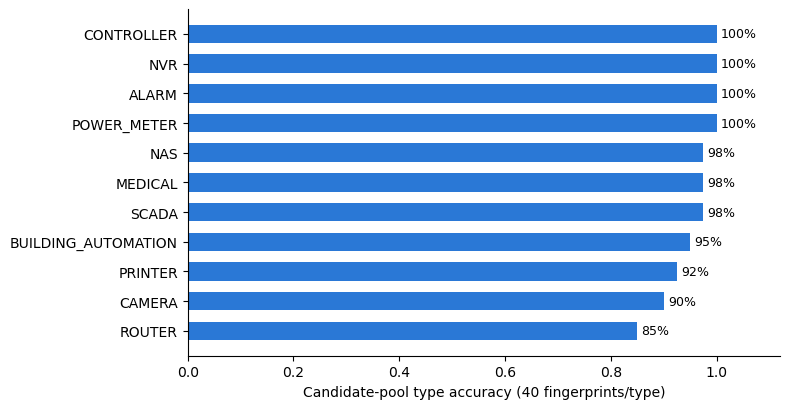

In [3]:
import matplotlib.pyplot as plt
d = df.sort_values('Accuracy')
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(d['Type'], d['Accuracy'], color='#2a78d6', height=0.62)
for b, v in zip(bars, d['Accuracy']):
    ax.text(v + 0.008, b.get_y() + b.get_height()/2, f'{v:.0%}', va='center', fontsize=9)
ax.set_xlim(0, 1.12); ax.set_xlabel('Candidate-pool type accuracy (40 fingerprints/type)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 2. Per-Case Results (Type · Vendor · Confidence · Novelty · Drift)

In [4]:
rows = []
for t, cs in cases.items():
    for c in cs:
        r, dr = c['result'], c.get('drift', {})
        rows.append({'Type': t, 'IP': c['ip'],
                     'Prediction': f"{r['classified_type']} / {r['classified_vendor']}",
                     'Type confidence': round(r['type_confidence'], 4),
                     'Vendor confidence': round(r['vendor_confidence'], 4),
                     'Novelty (type/vendor)': f"{r['new_type_probability']:.2f} / {r['new_vendor_probability']:.2f}",
                     'Drift score': dr.get('drift_score'), 'Is drift?': dr.get('is_drift')})
pd.DataFrame(rows)

,Type,IP,Prediction,Type confidence,Vendor confidence,Novelty (type/vendor),Drift score,Is drift?
0,NAS,86.194.248.180,NAS / Synology,0.9999,0.9985,0.00 / 0.00,1.1807,False
1,NAS,88.84.240.38,NAS / D-Link,0.9994,0.9999,0.00 / 0.00,22.5853,True
2,NAS,61.40.19.90,NAS / Hanwha,0.9551,0.9777,0.00 / 0.00,2.6714,False
3,NVR,109.81.182.57,NVR / Merit Lilin,1.0000,0.9362,0.00 / 0.00,2.3809,False
4,NVR,193.114.37.180,NVR / Huawei,1.0000,0.7607,0.00 / 0.00,5.4779,False
5,NVR,210.130.137.146,NVR / Hikvision,1.0000,0.9955,0.00 / 0.00,19.5382,True
6,POWER_METER,12.13.105.243,POWER_METER / eGauge,0.9998,0.9996,0.00 / 0.00,17.1045,True
7,POWER_METER,178.242.174.54,POWER_METER / Schneider Electric,0.9996,1.0000,0.00 / 0.00,14.3702,True
8,POWER_METER,63.46.75.110,POWER_METER / Sierra Wireless,0.9995,0.9904,0.00 / 0.00,24.7670,True
9,BUILDING_AUTOMATION,71.83.143.206,BUILDING_AUTOMATION / Bosch,0.9998,1.0000,0.00 / 0.00,6.2049,False


## 3. Single-Case Inspection (Edit `T` / `i` to Select a Case)

Among the 11 fingerprint views, certificate, hardware, software, and favicon features carry high discriminative weight.

In [5]:
T, i = 'CAMERA', 0
c = cases[T][i]
print(f"IP {c['ip']}  →  {c['result']['classified_type']} / {c['result']['classified_vendor']}"
      f"  (type_conf={c['result']['type_confidence']:.4f})")
print(f"drift score={c['drift'].get('drift_score')} (τ=8.78, is_drift={c['drift'].get('is_drift')})")
if 'local_retrieval_neighbours' in c:
    print('Vector nearest neighbors:', [(n['ip'], n['similarity']) for n in c['local_retrieval_neighbours'][:3]])
fp = c['fingerprint']
for k in ['cert-subjects','hw-vendors','hw-products','sw-vendors','os-vendor','http-info','dns-reverse']:
    if fp.get(k): print(f"  {k:14}: {str(fp[k])[:90]}")

IP 46.20.187.135  →  CAMERA / Macroscopic  (type_conf=1.0000)
drift score=12.8116 (τ=8.78, is_drift=True)
Vector nearest neighbors: [('202.82.81.19', 0.6909), ('75.205.240.185', 0.6907), ('49.128.162.163', 0.688)]
  cert-subjects : CN=*.arriah.ru
  hw-vendors    : Unknown
  hw-products   : Unknown
  sw-vendors    : Unknown,openbsd,f5,f5
  os-vendor     : canonical
  http-info     : HTTP-3189: (html body: {endpoint0: <!doctype html><html lang="ru"><head><meta charset="UTF


## 4. Optional Web Interface

Live recognition is available in the first code cell. You can also launch the web interface with:
`cd demo && python app.py` → http://localhost:5001